# Phase 2 — Supervised Training Results
Loads all finished runs from MLflow and compares Logistic Regression, Random Forest, and XGBoost across binary and multi-class tasks.


In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from mlflow.tracking import MlflowClient
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

ROOT   = Path('../')
PROC   = ROOT / 'data' / 'processed'
mlflow.set_tracking_uri(str(ROOT / 'mlruns'))
client = MlflowClient()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

/Users/apple/Desktop/NetGuardAI/.venv/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## 1  Pull runs from MLflow

In [2]:
def fetch_runs(experiment_name):
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        raise RuntimeError(f"Experiment '{experiment_name}' not found.")
    runs = client.search_runs(
        exp.experiment_id,
        filter_string="attributes.status = 'FINISHED'",
        order_by=["metrics.f1_weighted DESC"],
    )
    rows = []
    for r in runs:
        row = {'model': r.data.tags.get('model', r.info.run_id)}
        row.update(r.data.metrics)
        rows.append(row)
    return pd.DataFrame(rows).set_index('model')

binary_df = fetch_runs('netguardai_binary')
multi_df  = fetch_runs('netguardai_multiclass')

print('Binary runs:')
display(binary_df.round(4))
print('\nMulti-class runs:')
display(multi_df.round(4))

Binary runs:


,recall_weighted,accuracy,f1_weighted,roc_auc,precision_weighted,f1_macro
model,,,,,,
xgboost,0.9915,0.9915,0.9915,0.9999,0.9916,0.9903
random_forest,0.9807,0.9807,0.9806,0.9981,0.9812,0.9779
logistic_regression,0.8733,0.8733,0.8762,0.9666,0.8922,0.8648



Multi-class runs:


,recall_weighted,accuracy,f1_weighted,precision_weighted,f1_macro
model,,,,,
xgboost,0.9947,0.9947,0.9963,0.9980,0.1659
random_forest,0.9873,0.9873,0.9919,0.9966,0.1802
random_forest,0.9672,0.9672,0.9618,0.9566,0.1508
logistic_regression,0.7567,0.7567,0.8529,0.9916,0.1352
logistic_regression,0.7413,0.7413,0.8292,0.9563,0.1161
logistic_regression,0.7413,0.7413,0.8292,0.9563,0.1161


## 2  Metric comparison bar charts

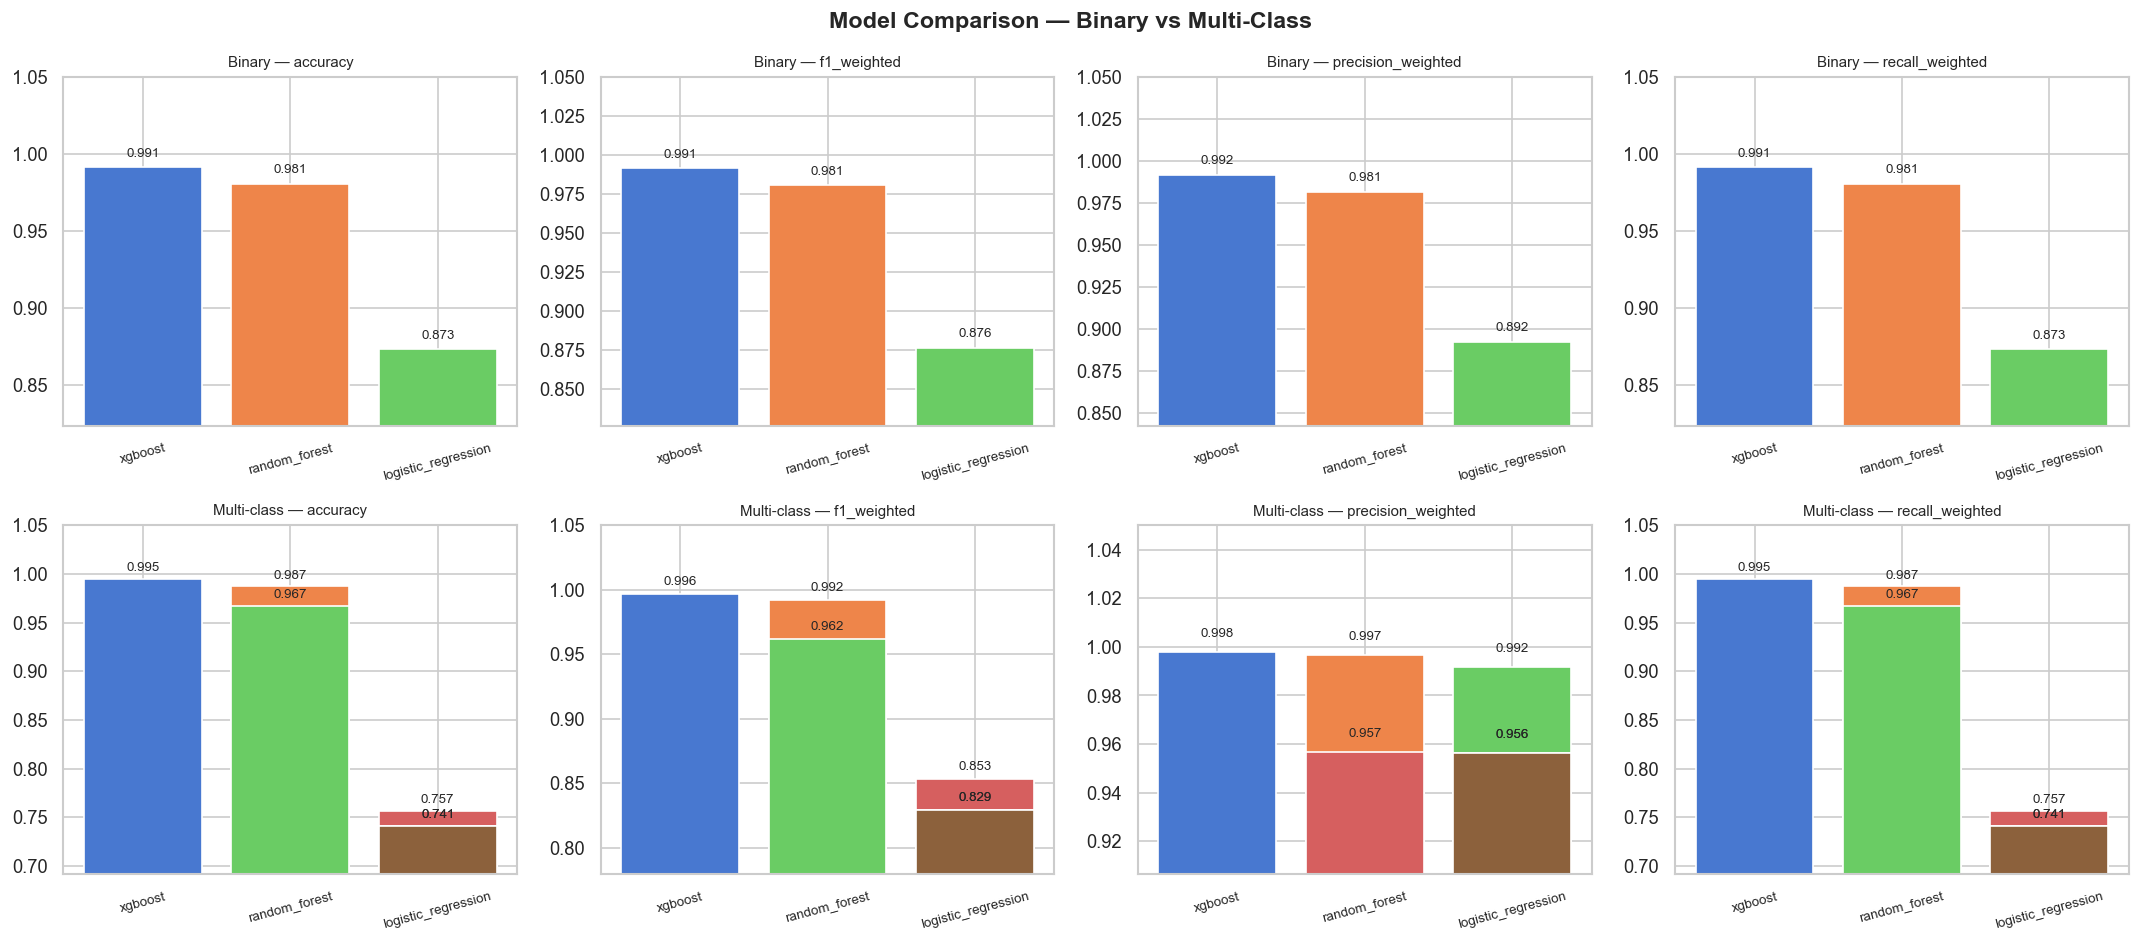

In [3]:
metrics_to_plot = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
fig.suptitle('Model Comparison — Binary vs Multi-Class', fontsize=14, fontweight='bold')

for col, metric in enumerate(metrics_to_plot):
    for row, (df, title) in enumerate([(binary_df, 'Binary'), (multi_df, 'Multi-class')]):
        ax = axes[row][col]
        if metric in df.columns:
            vals = df[metric].sort_values(ascending=False)
            bars = ax.bar(vals.index, vals.values,
                          color=sns.color_palette('muted', len(vals)))
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
            ax.set_ylim(max(0, vals.min() - 0.05), 1.05)
        ax.set_title(f'{title} — {metric}', fontsize=9)
        ax.tick_params(axis='x', rotation=15, labelsize=8)

plt.tight_layout()
plt.savefig('../data/processed/supervised_comparison.png', bbox_inches='tight')
plt.show()

## 3  ROC-AUC (binary only)

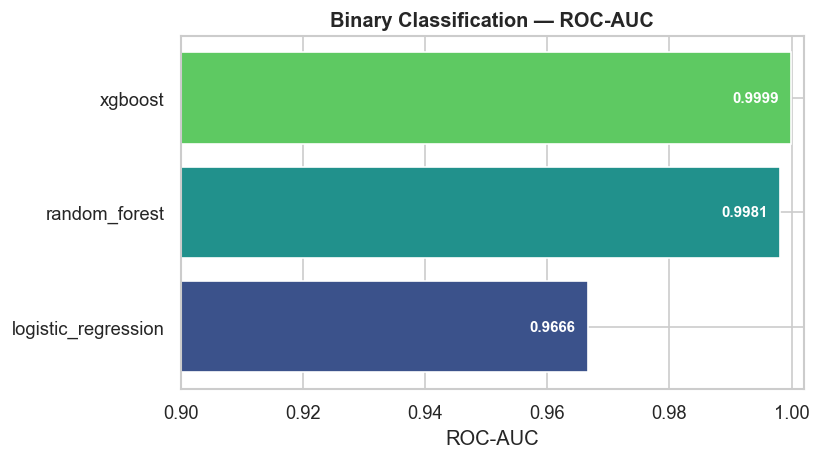

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
roc = binary_df['roc_auc'].sort_values(ascending=True)
bars = ax.barh(roc.index, roc.values, color=sns.color_palette('viridis', len(roc)))
for bar in bars:
    ax.text(bar.get_width() - 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', ha='right', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_xlim(0.9, 1.002)
ax.set_title('Binary Classification — ROC-AUC', fontsize=12, fontweight='bold')
ax.set_xlabel('ROC-AUC')
plt.tight_layout()
plt.show()

## 4  Confusion matrices (best model per task — XGBoost)

In [5]:
import mlflow.sklearn

def load_best_model(experiment_name):
    exp  = client.get_experiment_by_name(experiment_name)
    runs = client.search_runs(
        exp.experiment_id,
        filter_string="attributes.status = 'FINISHED'",
        order_by=["metrics.f1_weighted DESC"],
        max_results=1,
    )
    run = runs[0]
    model_uri = f"runs:/{run.info.run_id}/model"
    print(f"Loading {run.data.tags.get('model')} from {experiment_name}")
    return mlflow.sklearn.load_model(model_uri), run.data.tags.get('model')

# Load data
X_test        = np.load(PROC / 'X_test.npy')
y_test_bin    = np.load(PROC / 'y_test_binary.npy')
y_test_multi  = np.load(PROC / 'y_test_multi.npy')
with open(PROC / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Multi-class: filter to classes seen during training
train_class_idx = sorted(set(y_test_multi.tolist()) - set([3, 8]))  # DoS GoldenEye=3, Heartbleed=8 absent
# Re-derive which indices are in train by checking y_train_multi
y_train_multi = np.load(PROC / 'y_train_multi.npy')
train_class_idx = sorted(np.unique(y_train_multi).tolist())
remap = {old: new for new, old in enumerate(train_class_idx)}
test_known = np.isin(y_test_multi, train_class_idx)
y_test_multi_r = np.array([remap[c] for c in y_test_multi[test_known]])
X_test_m = X_test[test_known]
multi_names = [le.classes_[i] for i in train_class_idx]

# Load best models
model_bin,   name_bin   = load_best_model('netguardai_binary')
model_multi, name_multi = load_best_model('netguardai_multiclass')

Loading xgboost from netguardai_binary
Loading xgboost from netguardai_multiclass


/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_60998/2281841511.py:19: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_60998/2281841511.py:20: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig('../data/processed/confusion_matrices.png', bbox_inches='tight')
/Users/apple/Desktop/NetGuardAI/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


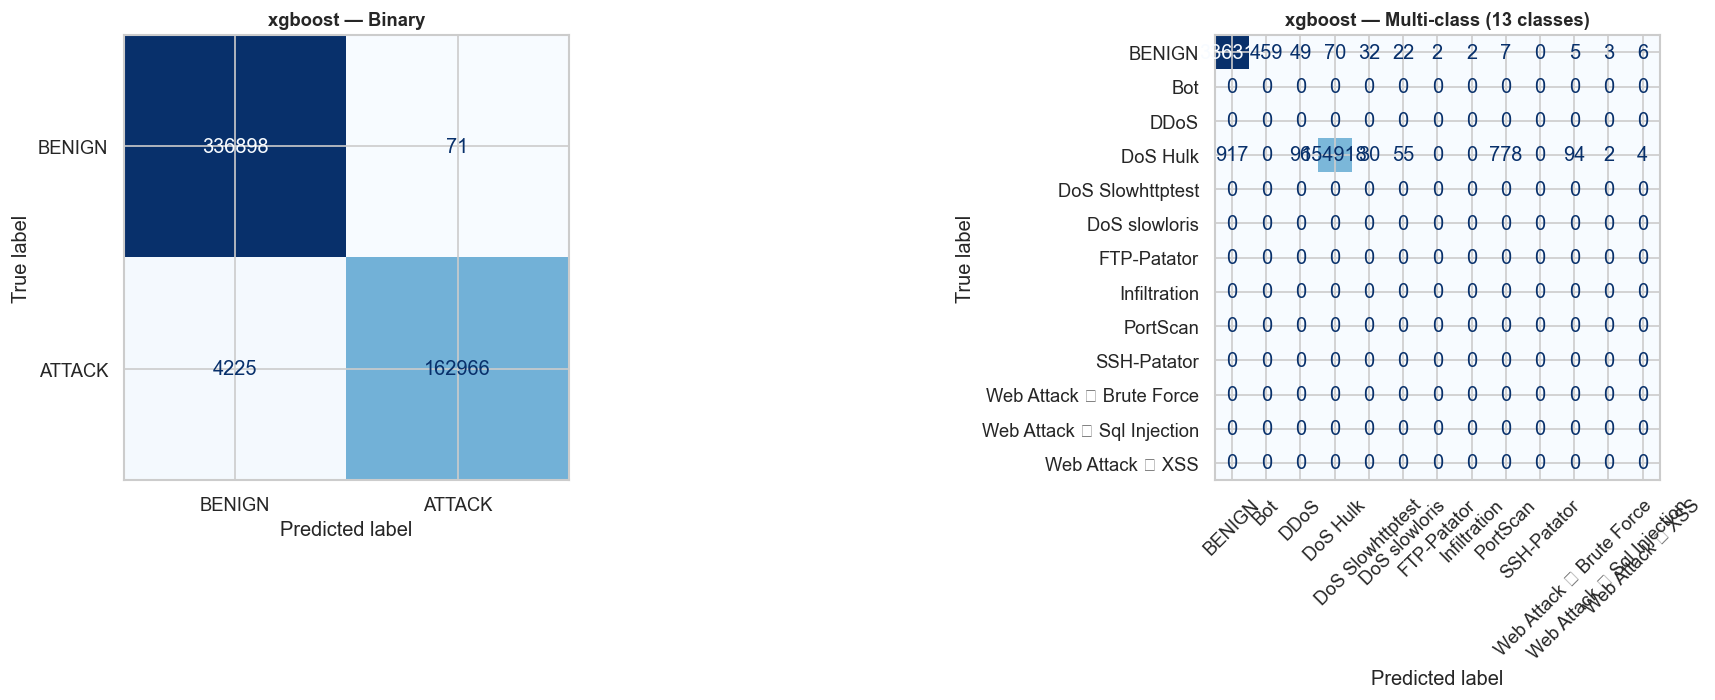

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Binary
y_pred_bin = model_bin.predict(X_test)
cm_bin = confusion_matrix(y_test_bin, y_pred_bin, labels=[0, 1])
ConfusionMatrixDisplay(cm_bin, display_labels=['BENIGN', 'ATTACK']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'{name_bin} — Binary', fontsize=11, fontweight='bold')

# Multi-class: force all 13 labels to appear even if some weren't predicted
n_classes    = len(multi_names)
y_pred_multi = model_multi.predict(X_test_m)
cm_multi     = confusion_matrix(y_test_multi_r, y_pred_multi, labels=list(range(n_classes)))
disp = ConfusionMatrixDisplay(cm_multi, display_labels=multi_names)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues', xticks_rotation=45)
axes[1].set_title(f'{name_multi} — Multi-class (13 classes)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices.png', bbox_inches='tight')
plt.show()

## 5  Classification report (best binary model)

In [7]:
from sklearn.metrics import classification_report
print(classification_report(y_test_bin, y_pred_bin, target_names=['BENIGN', 'ATTACK']))

              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99    336969
      ATTACK       1.00      0.97      0.99    167191

    accuracy                           0.99    504160
   macro avg       0.99      0.99      0.99    504160
weighted avg       0.99      0.99      0.99    504160

